#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from diffusers import DDPMScheduler, ScoreSdeVeScheduler

Instantiating the schedulers.

In [11]:
T = 1000
t_continuous = np.linspace(0, 1, T)

vp_scheduler = DDPMScheduler(
    num_train_timesteps=T,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear"
)

ve_scheduler = ScoreSdeVeScheduler(
    num_train_timesteps=T,
    sigma_min=0.01,
    sigma_max=50.0
)

alphas_cumprod = vp_scheduler.alphas_cumprod.numpy()
var_vp = 1.0 - alphas_cumprod

var_sub_vp = (1.0 - alphas_cumprod) ** 2

if hasattr(ve_scheduler, 'discrete_sigmas'):
    sigmas = ve_scheduler.discrete_sigmas.numpy()
else:
    sigmas = ve_scheduler.sigmas.numpy()

var_ve = sigmas ** 2

Plotting the variances from different SDEs.

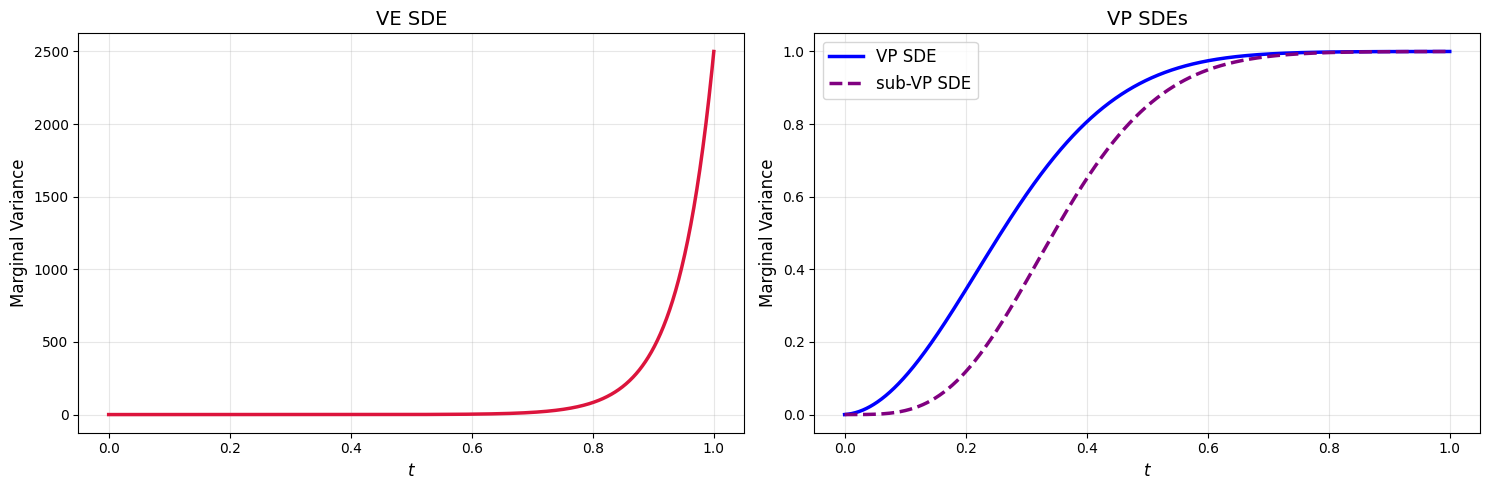

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(t_continuous, var_ve, color='crimson', linewidth=2.5)
axes[0].set_title("VE SDE", fontsize=14)
axes[0].set_xlabel(r"$t$", fontsize=12)
axes[0].set_ylabel("Marginal Variance", fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_continuous, var_vp, label='VP SDE', color='blue', linewidth=2.5)
axes[1].plot(t_continuous, var_sub_vp, label='sub-VP SDE', color='purple', linestyle='--', linewidth=2.5)
axes[1].set_title("VP SDEs", fontsize=14)
axes[1].set_xlabel(r"$t$", fontsize=12)
axes[1].set_ylabel("Marginal Variance", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()